In [194]:
import pandas as pd
from geographiclib.geodesic import Geodesic
import math
import folium
geod = Geodesic.WGS84 
import datetime
from shapely.geometry import Point
from shapely.geometry import Polygon
import geopandas
import random
import numpy as np
import geopy
from geopy.distance import geodesic
import matplotlib.pyplot as plt

In [141]:
geod = Geodesic.WGS84 
data = 'obc_tanker_cargo.csv'
df = pd.read_csv(data)
bound = pd.read_csv('obc_boundaries.csv')
df = df.drop_duplicates(subset=['PERIOD', 'MMSI'])
df = df[['MMSI', 'LAT_AVG', 'LON_AVG', 'PERIOD', 'COG_DEG', 'HEADING_DEG', 'NAV_STATUS', 'DIM_BOW', 'DIM_STERN', 'DIM_PORT', 'DIM_STARBOARD', 'DRAUGHT', 'SPEED_KNOTS']]

In [68]:
df['MMSI'].shape

(131308,)

In [142]:
bound['geometry'] = bound.apply(lambda x: (float(x.Long), float(x.Lat)), axis=1)
channel_coords = list(bound['geometry'])
channel_coords_north = [channel_coords[0], channel_coords[1], channel_coords[2], channel_coords[3], channel_coords[-1], channel_coords[-2], channel_coords[-3], channel_coords[-4]]
channel_coords_south = [channel_coords[4], channel_coords[5], channel_coords[6], channel_coords[7], channel_coords[-1], channel_coords[-2], channel_coords[-3], channel_coords[-4]]
coords_north = [channel_coords[0], channel_coords[1], channel_coords[2], (-77.44235, 22.18378333), (-77.44235, 23.80836667), (-78.72296667, 23.80836667)]
coords_south = [channel_coords[4], channel_coords[5], channel_coords[6], channel_coords[7], (-77.4681,21.15348333), (-78.75143333, 21.15348333)]
channel_polygon_n = Polygon(channel_coords_north)
channel_polygon_s = Polygon(channel_coords_south)
polygon_n = Polygon(coords_north)
polygon_s = Polygon(coords_south)

In [143]:
my_map = folium.Map(location=[22.5, -77.8], zoom_start=9.45)
folium.GeoJson(channel_polygon_s, color='green').add_to(my_map)
folium.GeoJson(channel_polygon_n, color='orange').add_to(my_map)
#folium.GeoJson(polygon_s, color='blue').add_to(my_map)
#folium.GeoJson(polygon_n, color='red').add_to(my_map)
my_map2 = folium.Map(location=[22.5, -77.8], zoom_start=9.45)
folium.GeoJson(channel_polygon_s, color='green').add_to(my_map2)
folium.GeoJson(channel_polygon_n, color='orange').add_to(my_map2)

my_map3 = folium.Map(location=[22.5, -77.8], zoom_start=9.45)
folium.GeoJson(channel_polygon_s, color='green').add_to(my_map3)
folium.GeoJson(channel_polygon_n, color='orange').add_to(my_map3)

In [71]:
def where_is_vessel(LAT_AVG, LON_AVG, BOOL_northc, BOOL_southc, BOOL_north, BOOL_south):
    if BOOL_northc == True:
        answer = 'in north channel'
    elif BOOL_southc == True:
        answer = 'in south channel'
    elif LON_AVG < -78.72296667:
        answer = 'west'
    elif LON_AVG > -77.49385:
        answer = 'east'
    elif BOOL_north == True:
        answer = 'north'
    elif BOOL_south == True:
        answer = 'south'
    else:
        answer = 'other'
    return answer

In [72]:
def correct_side(location, channel_side):
    if (location == 'in north channel') and (channel_side == 'Northwestbound'):
        return True
    elif (location == 'in south channel') and (channel_side == 'Southeastbound'):
        return True
    elif (location == 'in south channel') or (location == 'in north channel'):
        return False
    else:
        return None

In [73]:
def location_diff(location, prev_location):
    if location == prev_location:
        return 'same'
    elif prev_location == None:
        return None
    elif ((location == 'in north channel') and (prev_location == 'east')) or ((location == 'in south channel') and (prev_location == 'west')):
        return 'enter channel'
    elif ((location == 'west') and (prev_location == 'in north channel')) or ((location == 'east') and (prev_location == 'in south channel')):
        return 'exit channel'
    elif ((location == 'in north channel') and (prev_location == 'in south channel')) or ((location == 'in south channel') and (prev_location == 'in north channel')):
        return 'cross channel'
    elif ((location != 'west') and (prev_location == 'in north channel')) or ((location != 'east') and (prev_location == 'in south channel')):
        return 'abnormal exit'
    elif ((location == 'in north channel') and (prev_location != 'east')) or ((location == 'in south channel') and (prev_location != 'west')):
        return 'abnormal enter'
    else:
        return 'other'

In [188]:
def row_anom(cog_diff, sog, nav_status, pred, dist_threshold, error_nm, num_pings, correct_side, location, voyage_id, location_diff):
    score = 0
    flags = []
    if cog_diff > 75:
        score += 1
        flags.append('COG')
    if sog < 5 and (nav_status != 1 or nav_status != 2 or nav_status !=3 or nav_status != 5 or nav_status != 6):
        score += 1
        flags.append('SOG')
    if (pred == True) and (error_nm > 0):
        if error_nm > dist_threshold:
            score += (2 / (num_pings - 7))
            flags.append('dist_pred')
    if correct_side == False:
        score += 1
        flags.append('correct_side')
    if location == 'south' and voyage_id[:3] != '323':
        score += 1
        flags.append('south')
    if location == 'north' and (voyage_id[:3] != '308' and voyage_id[:3] != '309' and voyage_id[:3] != '311'):
        score += 1
        flags.append('north')
    if location_diff == 'abnormal exit' or location_diff == 'abnormal enter' or location_diff == 'cross channel':
        score += 1
        flags.append('exit/entrance/cross')
    return score, flags
    

In [75]:
def voyage_anom(beam, length, nav_status):
    score = 0
    if beam == 0:
        score += 1
    if length == 0:
        score += 1
    if (nav_status == 1) or (nav_status == 2) or (nav_status == 5) or (nav_status == 6) or (nav_status == 7) or (nav_status == 8):
        score += 1
    return score

Create Variables

In [144]:
df['BEAM'] = df['DIM_PORT'] + df['DIM_STARBOARD']
df['LENGTH'] = df['DIM_BOW'] + df['DIM_STERN']
df['PERIOD'] = pd.to_datetime(df['PERIOD'])

df = df.sort_values(['MMSI', 'PERIOD']).reset_index(drop=True)
df['time_diff'] = (df.groupby('MMSI')['PERIOD'].diff().dt.total_seconds())
threshold = 30 * 60
df['new_voyage'] = (df['time_diff'] > threshold) | (df['time_diff'] < 0 ) | (df['time_diff'].isna())
df['voyage_id'] = (df.groupby('MMSI')['new_voyage'].cumsum())
df['voyage_id'] = df['voyage_id'].astype('str') + '_' + df['MMSI'].astype('str')
df['num_pings'] = df['voyage_id'].map(df['voyage_id'].value_counts())
df = df[df['num_pings'] >= 8]
df['row_id'] = df['voyage_id'].astype('str') + '_' + df.groupby('voyage_id').cumcount().astype('str')
#df.to_csv('mid_datav4.csv')

In [145]:
tcn_results = pd.read_csv('tcn_pred_final_7.csv', header=0)
tcn_voyages = set(tcn_results['voyage_id'])
tcn_results['row_id'] = tcn_results['voyage_id'] + '_' + tcn_results['row_id'].astype('str')
tcn_results['error_yds_tcn'] = tcn_results['error_m'] * 1.0936133
tcn_results = tcn_results[['delta_t', 'pred_lat', 'pred_lon', 'error_yds_tcn', 'row_id']]

In [146]:
dr_results = pd.read_csv('mid_datav4_with_dr.csv', header = 0)
dr_results['error_yds_dr'] = dr_results['error_yds']
dr_results = dr_results[['error_yds_dr', 'row_id']]

In [147]:
df = pd.merge(df, tcn_results, on='row_id', how='left')

In [148]:
df = pd.merge(df, dr_results, on='row_id', how = 'left')

In [149]:
df['tcn_pred'] = df['voyage_id'].isin(tcn_voyages)

In [103]:
df['voyage_id'].nunique()

2792

In [150]:
df['cog_diff'] = (df.groupby('voyage_id')['COG_DEG'].diff())
df['cog_diff'] = np.abs((df['cog_diff'] + 180) % 360 -180)
df['channel_side'] = ['Northwestbound' if x > 200 else 'Southeastbound' for x in df['COG_DEG']]

In [151]:
geo_df = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df['LON_AVG'], df['LAT_AVG']), crs='EPSG:4326')
geo_df['in_channel_north'] = geo_df.within(channel_polygon_n)
geo_df['in_channel_south'] = geo_df.within(channel_polygon_s)
geo_df['in_north'] = geo_df.within(polygon_n)
geo_df['in_south'] = geo_df.within(polygon_s)
geo_df['location'] = geo_df.apply(lambda x: where_is_vessel(x.LAT_AVG, x.LON_AVG, x.in_channel_north, x.in_channel_south, x.in_north, x.in_south), axis=1)
geo_df['correct_side'] = geo_df.apply(lambda y: correct_side(y.location, y.channel_side), axis=1)

In [152]:
geo_df['prev_location'] = geo_df['location'].shift()
geo_df.loc[geo_df['new_voyage'] == True, 'prev_location'] = None
geo_df['location_diff'] = geo_df.apply(lambda y: location_diff(y.location, y.prev_location), axis=1)

In [153]:
#geo_df = geo_df[geo_df['tcn_pred']==True].copy()
geo_df['error_yds_tcn'].describe()
q1 = 579.853059
q3 = 1898.409328
dist_threshold_tcn = q3 + (1.5 * (q3 - q1))
dist_threshold_tcn

3876.2437314999997

In [154]:
print(geo_df['error_yds_dr'].describe())
q1 = 148.915659
q3 = 948.064122
dist_threshold_dr = q3 + (1.5 * (q3 - q1))

count     8578.000000
mean       647.934147
std        876.873966
min          0.811358
25%        148.915659
50%        458.587624
75%        948.064122
max      29252.954900
Name: error_yds_dr, dtype: float64


In [190]:
include_pred = False
geo_df[['row_score', 'row_flag']] = geo_df.apply(lambda y: row_anom(y.cog_diff, y.SPEED_KNOTS, y.NAV_STATUS, include_pred, dist_threshold_tcn, y.error_yds_tcn, y.num_pings, y.correct_side, y.location, y.voyage_id, y.location_diff), axis=1, result_type='expand')

Text(0, 0.5, 'Counts')

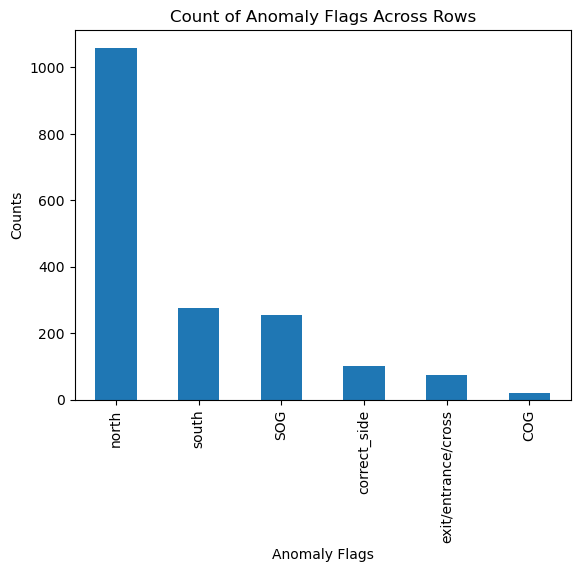

In [196]:
flag_counts = geo_df.explode('row_flag')['row_flag'].value_counts()
flag_counts.plot(kind = 'bar')
plt.title('Count of Anomaly Flags Across Rows')
plt.xlabel('Anomaly Flags')
plt.ylabel('Counts')

In [157]:
include_pred = True
geo_df['row_score_tcn'] = geo_df.apply(lambda y: row_anom(y.cog_diff, y.SPEED_KNOTS, y.NAV_STATUS, include_pred, dist_threshold_tcn, y.error_yds_tcn, y.num_pings, y.correct_side, y.location, y.voyage_id, y.location_diff), axis=1, result_type='expand')

In [160]:
include_pred = True
geo_df['row_score_dr'] = geo_df.apply(lambda y: row_anom(y.cog_diff, y.SPEED_KNOTS, y.NAV_STATUS, include_pred, dist_threshold_dr, y.error_yds_dr, y.num_pings, y.correct_side, y.location, y.voyage_id, y.location_diff), axis=1)

In [161]:
geo_df['voyage_score'] = geo_df.groupby('voyage_id')['row_score'].transform('sum')

In [162]:
geo_df['voyage_score_tcn'] = geo_df.groupby('voyage_id')['row_score_tcn'].transform('sum')

In [163]:
geo_df['voyage_score_dr'] = geo_df.groupby('voyage_id')['row_score_dr'].transform('sum')

In [164]:
geo_df['voyage_score'] += geo_df.apply(lambda y: voyage_anom(y.BEAM, y.LENGTH, y.NAV_STATUS), axis=1)

In [165]:
geo_df['voyage_score_tcn'] += geo_df.apply(lambda y: voyage_anom(y.BEAM, y.LENGTH, y.NAV_STATUS), axis=1)

In [166]:
geo_df['voyage_score_dr'] += geo_df.apply(lambda y: voyage_anom(y.BEAM, y.LENGTH, y.NAV_STATUS), axis=1)

In [167]:
anom_data = geo_df[geo_df['voyage_score'] > 2]
anom_data_tcn = geo_df[geo_df['voyage_score_tcn'] > 2]
anom_data_dr = geo_df[geo_df['voyage_score_dr'] > 2]

In [172]:
anom_voyage = set(anom_data['voyage_id'])
tcn_voyage = set(anom_data_tcn['voyage_id'])
dr_voyage = set(anom_data_dr['voyage_id'])
tcn_helped = (tcn_voyage-anom_voyage)
dr_helped = (dr_voyage-anom_voyage)
dr_helped

{'10_210740000',
 '15_563050500',
 '18_563050500',
 '1_209425000',
 '1_305723000',
 '1_311001226',
 '1_538009599',
 '1_636020861'}

In [26]:
anom_data.to_csv('anom_datav4.csv')

<Axes: >

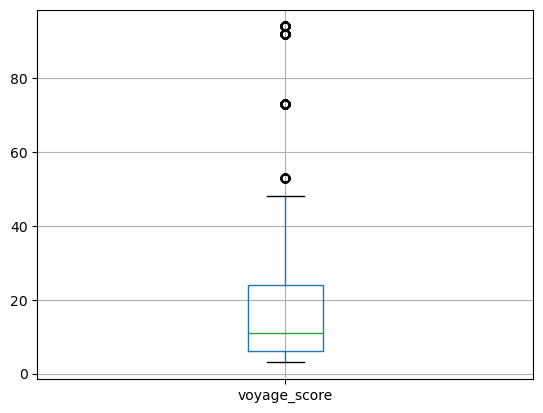

In [186]:
anom_data.boxplot(column =['voyage_score'])

In [185]:
anom_data_top = anom_data[anom_data['voyage_score'] >20]
anom_data_top['voyage_id'].nunique()

12

In [180]:
anom_data_dr = anom_data_dr[anom_data_dr['voyage_id'].isin(dr_helped)]

In [183]:
def rand_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

for id, vessel in anom_data_dr.groupby('voyage_id'):
    coords = list(vessel[['LAT_AVG', 'LON_AVG']].itertuples(index=False, name=None))
    #if len(coords) < 2:
        #continue

    folium.PolyLine(
        coords,
        color=rand_color(),
        weight=2,
        opacity=0.8,
        popup=f"MMSI: {id}"
    ).add_to(my_map)

my_map

In [187]:

def rand_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

for id, vessel in anom_data_top.groupby('voyage_id'):
    coords = list(vessel[['LAT_AVG', 'LON_AVG']].itertuples(index=False, name=None))
    if len(coords) < 2:
        continue

    folium.PolyLine(
        coords,
        color=rand_color(),
        weight=2,
        opacity=0.8,
        popup=f"MMSI: {id}"
    ).add_to(my_map2)

my_map2

In [86]:
x= df[df['tcn_pred']==True]
x['voyage_id'].nunique()

165

In [87]:
def rand_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

for id, vessel in x.groupby('voyage_id'):
    coords = list(vessel[['LAT_AVG', 'LON_AVG']].itertuples(index=False, name=None))
    if len(coords) < 2:
        continue

    folium.PolyLine(
        coords,
        color=rand_color(),
        weight=2,
        opacity=0.8,
        popup=f"MMSI: {id}"
    ).add_to(my_map3)

my_map3

In [86]:
gold = pd.read_csv('golden_datasetv5.csv')
gold.shape

(29733, 29)